In [7]:
import networkx as nx
import random
from collections import defaultdict
import matplotlib.pyplot as plt
import random
from collections import defaultdict, Counter
import matplotlib.pyplot as plt


def regularize_degrees(G, target_degree=None):
    """
    Modifies the graph G to make more nodes have the same degree.
    Returns a modified copy of the graph.
    
    Parameters:
    - G: input graph (NetworkX Graph)
    - target_degree: if None, it will use the mode of the degree distribution
    """
    G = G.copy()
    degrees = dict(G.degree())
    
    # Choose the target degree (most common one if not provided)
    if target_degree is None:
        degree_counts = defaultdict(int)
        for d in degrees.values():
            degree_counts[d] += 1
        target_degree = max(degree_counts.items(), key=lambda x: x[1])[0]

    print(f"Target degree: {target_degree}")

    # Adjust degrees
    for node in G.nodes():
        current_degree = G.degree(node)
        
        # Add edges if degree is too low
        while G.degree(node) < target_degree:
            potential_nodes = [n for n in G.nodes() 
                               if n != node and not G.has_edge(node, n) and G.degree(n) < target_degree]
            if not potential_nodes:
                break
            chosen = random.choice(potential_nodes)
            G.add_edge(node, chosen)

        # Remove edges if degree is too high
        while G.degree(node) > target_degree:
            neighbors = list(G.neighbors(node))
            if not neighbors:
                break
            chosen = random.choice(neighbors)
            G.remove_edge(node, chosen)

    return G

In [ ]:
def plot_separate_degree_distributions(G_original, G_regularized):
    degrees_orig = [deg for _, deg in G_original.degree()]
    degrees_reg = [deg for _, deg in G_regularized.degree()]

    plt.figure(figsize=(12, 5))

    # Original graph
    plt.subplot(1, 2, 1)
    plt.hist(degrees_orig, bins=range(min(degrees_orig), max(degrees_orig)+2), edgecolor='black')
    plt.title("Original Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Number of Nodes")

    # Regularized graph
    plt.subplot(1, 2, 2)
    plt.hist(degrees_reg, bins=range(min(degrees_reg), max(degrees_reg)+2), edgecolor='black', color='green')
    plt.title("Regularized Degree Distribution")
    plt.xlabel("Degree")
    plt.ylabel("Number of Nodes")

    plt.tight_layout()
    plt.show()


Original degree distribution: {0: 4, 1: 4, 2: 2, 3: 4, 4: 3, 5: 2, 6: 3, 7: 1, 8: 4, 9: 3}
Target degree: 4


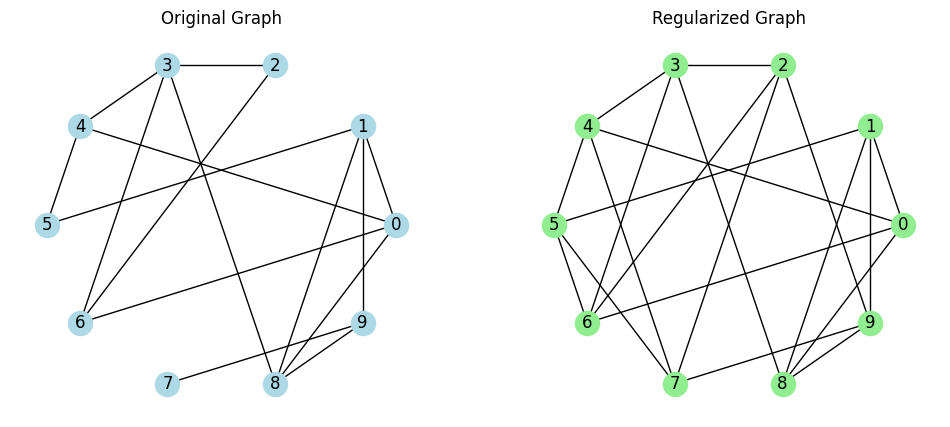

New degree distribution: {0: 4, 1: 4, 2: 4, 3: 4, 4: 4, 5: 4, 6: 4, 7: 4, 8: 4, 9: 4}


In [9]:
# Example: Create a sample irregular graph
G = nx.gnm_random_graph(n=10, m=15, seed=42)
print("Original degree distribution:", dict(G.degree()))

# Regularize
G_reg = regularize_degrees(G)

# Plot original and modified graphs
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
nx.draw_circular(G, with_labels=True, node_color="lightblue")
plt.title("Original Graph")

plt.subplot(1, 2, 2)
nx.draw_circular(G_reg, with_labels=True, node_color="lightgreen")
plt.title("Regularized Graph")

plt.show()

print("New degree distribution:", dict(G_reg.degree()))

Target degree: 4


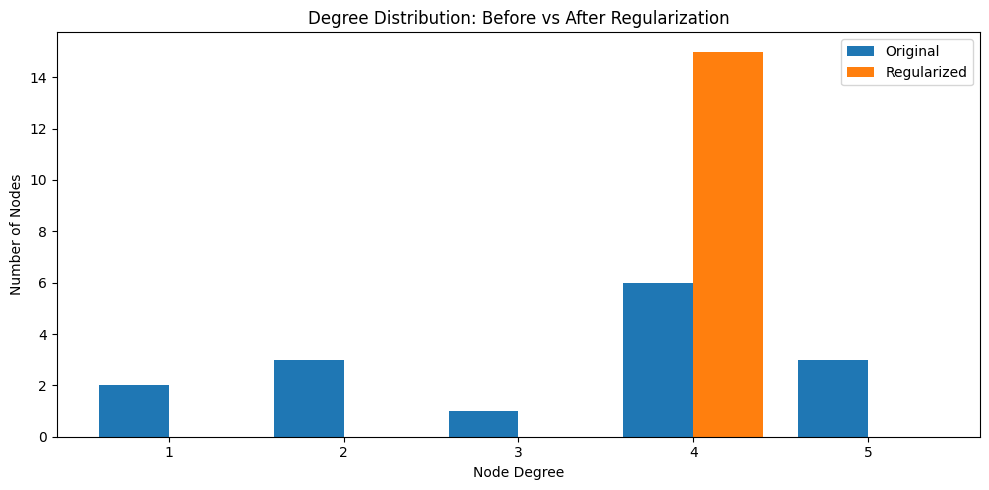

In [ ]:
G = nx.gnm_random_graph(n=15, m=25, seed=42)
G_reg = regularize_degrees(G)